# Which observables see which control: feature sensitivity, QFI and task gradient

## Statement of the problem
The mean-field lemma predicts that external squeezing is invisible in $\langle Q\rangle,\langle P\rangle$ and reaches the readout only through the second moments and the emitter. Test this on the features, and check the relation between quantum Fisher information (how much the state moves) and the task gradient (how much the loss moves), which the companion Fisher-bound paper says are related by conversion factors, not equal.

**Quantities** along lines through the Mackey–Glass basin: per-sample feature response $S_i=N_{\rm tr}^{-1/2}\|\partial X/\partial\vartheta_i\|_F$ (standardized, bias-centred), task-gradient magnitude $G_i=|\partial\mathcal L/\partial\vartheta_i|$, diagonal QFI $F_{ii}(t)=2\sum_{pq}|\langle p|\partial_i\rho_t|q\rangle|^2/(\lambda_p+\lambda_q)$ averaged over the training window; decomposition of $S_i^2$ by observable class; full gradient descent initialized along the lines.

In [1]:
import os, sys, subprocess, numpy as np
CODE = os.path.abspath(os.path.join(os.getcwd(), '..', 'code')); sys.path.insert(0, CODE); os.chdir(CODE); os.environ['OMP_NUM_THREADS'] = '1'
import matplotlib; matplotlib.use('Agg'); import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
from common import *
import make_figs
RUN = False   # set True to recompute the data for this notebook (see the "Compute" section for the cost)
def show(pdf, dpi=110):
    """Render a figure PDF from paper/figs inline."""
    base = '/tmp/' + os.path.basename(pdf)[:-4]; subprocess.run(['pdftoppm', '-r', str(dpi), '-png', '-singlefile', pdf, base], check=True); display(Image(filename=base + '.png'))
def ld(name):
    p = os.path.join(DATA, name); return np.load(p, allow_pickle=True) if os.path.exists(p) else None


## Compute
`run_fig4.py` (~15 min).

In [2]:
if RUN: subprocess.run(['python3', 'run_fig4.py'])
d = ld('fig4_lines.npz'); Sg = d['line_r'][0, 12:21].reshape(3, 3); fr = Sg**2 / (Sg**2).sum(1, keepdims=True)
for i, c in enumerate(('r', 're', 'dth')): print('S_%s^2 shares: means %.1f%%, second moments %.1f%%, emitter %.1f%%' % (c, *(100 * fr[i])))
print('median QFI per sample along re: %.2f; along dth: %.1e' % (np.median(d['line_re'][:, 7]), np.median(d['line_dth'][:, 8])))

S_r^2 shares: means 16.7%, second moments 61.4%, emitter 21.9%
S_re^2 shares: means 1.0%, second moments 90.1%, emitter 8.9%
S_dth^2 shares: means 0.3%, second moments 96.0%, emitter 3.7%
median QFI per sample along re: 5.20; along dth: 1.1e-03


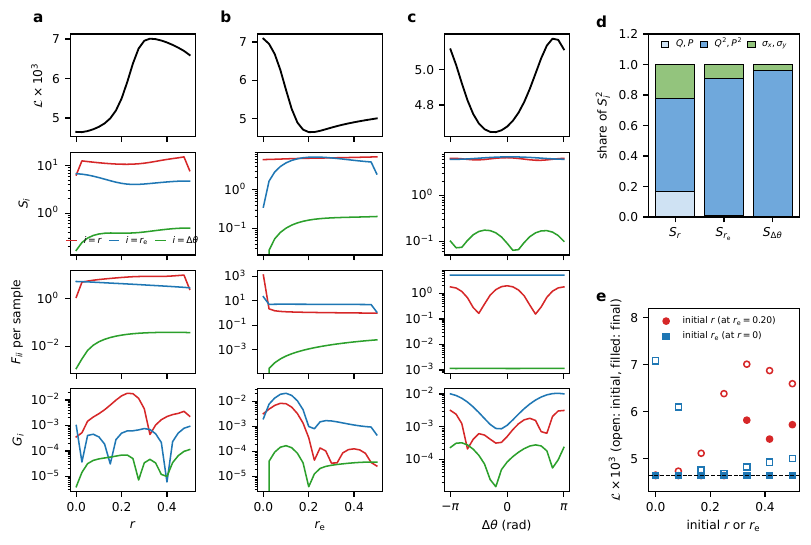

In [3]:
sc = ld('fig2_scans.npz'); make_figs.fig4(min(sc['L3'].min(), sc['L1'].min())); show('paper/figs/fig4_mech.pdf')

**Supplementary Figure (Note 9).** Along $r_e$ the QFI is large and flat while $G_{r_e}$ crosses zero at the basin; along $\Delta\theta$ the QFI is three orders smaller yet the phase gradient steers the optimizer. QFI is a budget, not a predictor. Panel d: the quadrature means carry 17% of $S_r^2$ but 1% of $S_{r_e}^2$ and 0.3% of $S_{\Delta\theta}^2$.